# Train Agent using RARL
Train agent and adversarial agents in HVAC environment

In [64]:
import gym
from gym import spaces
import numpy as np
import random
from collections import deque, namedtuple
import torch.nn as nn
import torch
from torch import manual_seed
import torch.nn.functional as F
import torch.optim as optim
import math
import matplotlib.pyplot as plt
from pythermalcomfort.models import pmv_ppd

In [98]:
"""
A custom Gym environment for simulating a building's HVAC system and user interactions.

Attributes:
    metadata (dict): Metadata for rendering modes.
    alpha (float): Weight for comfort penalty in reward calculation.
    beta (float): Weight for energy penalty in reward calculation.
    EER (float): Energy Efficiency Ratio for HVAC power calculation.
    seed_value (int): Seed for random number generation.
    rng (RandomState): Random number generator instance.
    room_width (int): Width of the room in the simulation.
    room_height (int): Height of the room in the simulation.
    action_space (Discrete): Action space for the environment.
    observation_space (Box): Observation space for the environment.
    adversary_action_space (Discrete): Action space for adversary actions.
    time_step (int): Current time step in the simulation.
    max_steps (int): Maximum number of steps per episode.
    indoor_temp (float): Current indoor temperature.
    setpoint_temp (float): Desired indoor temperature.
    outdoor_temp (float): Current outdoor temperature.
    occupancy_level (float): Current occupancy level.
    num_users (int): Number of users in the building.
    users (list): List of user attributes.
    user_feedback (float): Aggregated user feedback on comfort.
    hvac_power (float): Current power consumption of the HVAC system.
    history (dict): Historical data of the simulation.

Methods:
    generate_outdoor_temperature(): Generates the outdoor temperature based on time of day.
    generate_occupancy_level(): Generates the occupancy level based on time of day.
    generate_num_users(): Calculates the number of users based on occupancy level.
    generate_users(): Generates user attributes such as position and clothing level.
    generate_user_feedback(): Calculates user feedback based on PMV values.
    calculate_pmv(met, clo): Calculates the Predicted Mean Vote (PMV) for a user.
    step(action, adversary_action): Executes a simulation step with given actions.
    reset(): Resets the environment to its initial state.
    render(): Renders the environment (not implemented).
"""
class BuildingEnv(gym.Env):
    metadata = {'render.modes': ['human']}
    def __init__(self, alpha=1, beta=1, EER=11, seed=42):
        super(BuildingEnv, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.EER = EER
        
        #setting seed
        self.seed_value = seed
        random.seed(seed)
        np.random.seed(seed)
        manual_seed(seed)
        self.rng = np.random.RandomState(seed)  

        self.room_width, self.room_height = 800, 600
        self.action_space = spaces.Discrete(9) 
        low = np.array([-10.0, 0.0, -3.0]) 
        high = np.array([50.0, 1.0, 3.0])
        self.observation_space = spaces.Box(low, high)
        
        self.adversary_action_space = spaces.Discrete(3)

        self.time_step = 0
        self.max_steps = 48  

        self.indoor_temp = 26.0
        self.setpoint_temp = 26.0
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()

        self.num_users = self.generate_num_users()
        self.users = self.generate_users()

        self.user_feedback = self.generate_user_feedback()
        self.hvac_power = 0.0

        self.history = {
            'indoor_temp': [], 'outdoor_temp': [], 'hvac_power': [],
            'user_feedback': [], 'occupancy': [], 'time': []
        }

    def generate_outdoor_temperature(self):
        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        temp = 28 - 6 * np.cos((time_of_day - 14) * np.pi / 12)  # peaks at 2 PM
        return temp + self.rng.normal(0, 1.0)

    def generate_occupancy_level(self):
        time_of_day = (self.time_step % self.max_steps) / self.max_steps * 24.0
        if 9 <= time_of_day < 12 or 13 <= time_of_day < 17:  # Normal work hours
            occupancy = self.rng.uniform(0.5, 0.8)
        elif 12 <= time_of_day < 13:  # Lunch hour (peak)
            occupancy = self.rng.uniform(0.8, 1.0)
        elif 8 <= time_of_day < 9 or 17 <= time_of_day < 18:  # Transition hours
            occupancy = self.rng.uniform(0.2, 0.5)
        else:  # Off hours
            occupancy = self.rng.uniform(0.0, 0.1)
        return occupancy

    def generate_num_users(self):
        max_users = 1000
        return int(self.occupancy_level * max_users)

    def generate_users(self):
        users = []
        for _ in range(self.num_users):
            user = {
                'x': self.rng.randint(50, self.room_width - 50),
                'y': self.rng.randint(50, self.room_height - 50),
                'met': self.rng.uniform(1.0, 1.5),
                'clo': self.rng.uniform(0.5, 1.0)
            }
            users.append(user)
        return users

    def generate_user_feedback(self):
        if self.num_users == 0:
            return 0
        pmv_values = []
        for user in self.users:
            met = user['met']
            clo = user['clo']
            pmv = self.calculate_pmv(met, clo)
            pmv_values.append(pmv)
        aggregated_pmv = np.mean(pmv_values)
        return np.clip(aggregated_pmv, -3.0, 3.0)

    def calculate_pmv(self, met, clo):
        tdb = self.indoor_temp  # Dry bulb temperature
        tr = tdb  # Mean radiant temperature
        rh = 50.0  # Relative humidity
        v = 0.1  # Air velocity

        pmv_result = pmv_ppd(tdb=tdb, tr=tr, vr=v, rh=rh, met=met, clo=clo, standard='ASHRAE')
        return pmv_result['pmv']

    def step(self, action, adversary_action):
        self.setpoint_temp = 22 + action

        temp_difference = self.indoor_temp - self.setpoint_temp
        self.hvac_power = abs(temp_difference) * 10 / self.EER 

        outdoor_influence = (self.outdoor_temp - self.indoor_temp) * 0.1
        hvac_influence = (self.setpoint_temp - self.indoor_temp) * 0.5
        self.indoor_temp += outdoor_influence + hvac_influence

        self.time_step += 1
        done = self.time_step >= self.max_steps
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users = self.generate_num_users()
        self.users = self.generate_users()
        self.user_feedback = self.generate_user_feedback()
        
        if adversary_action == 1:
            self.user_feedback += 0.5
        elif adversary_action == 2:
            self.user_feedback -= 0.5

        self.user_feedback = np.clip(self.user_feedback, -3.0, 3.0)
        if self.num_users == 0:
            reward = -self.beta * (self.hvac_power / 1000.0)  
        else:
            comfort_penalty = abs(self.user_feedback) * self.occupancy_level
            energy_penalty = self.hvac_power / 1000.0
            reward = -(self.alpha * comfort_penalty + self.beta * energy_penalty)
        
        reward = reward / 10.0
        adversary_reward = -reward

        self.history['indoor_temp'].append(self.indoor_temp)
        self.history['outdoor_temp'].append(self.outdoor_temp)
        self.history['hvac_power'].append(self.hvac_power)
        self.history['user_feedback'].append(self.user_feedback)
        self.history['occupancy'].append(self.occupancy_level)
        self.history['time'].append(self.time_step)

        state = np.array([self.outdoor_temp, self.occupancy_level, self.user_feedback], dtype=np.float32)
        return state, reward, done, {}, adversary_reward

    def reset(self):
        # Reset RNG to initial seed + timestep to maintain determinism across episodes
        self.rng = np.random.RandomState(self.seed_value)
        
        self.time_step = 0
        self.indoor_temp = 26.0
        self.setpoint_temp = 26.0
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users = self.generate_num_users()
        self.users = self.generate_users()
        self.user_feedback = self.generate_user_feedback()
        self.hvac_power = 0.0

        for key in self.history.keys():
            self.history[key] = []

        state = np.array([self.outdoor_temp, self.occupancy_level, self.user_feedback], dtype=np.float32)
        return state

    def render(self):
        pass

In [99]:
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 256)
        self.layer2 = nn.Linear(256, 256)
        self.layer3 = nn.Linear(256, 128)
        self.layer4 = nn.Linear(128, n_actions)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.relu(self.layer3(x))
        return self.layer4(x)

class DQNAgent:
    def __init__(self, n_observations, n_actions, device, memory_size=10000, batch_size=64, gamma=0.99, eps_start=0.9, eps_end=0.05, eps_decay=2000, tau=0.005, lr=1e-3):
        self.n_observations = n_observations
        self.n_actions = n_actions
        self.device = device
        self.batch_size = batch_size
        self.gamma = gamma
        self.eps_start = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay 
        self.tau = tau
        self.lr = lr

        self.policy_net = DQN(n_observations, n_actions).to(device)
        self.target_net = DQN(n_observations, n_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayMemory(memory_size)

        self.steps_done = 0

    def select_action(self, state, train=True):
        if train:
            eps_threshold = self.eps_end + (self.eps_start - self.eps_end) * \
                math.exp(-1. * self.steps_done / self.eps_decay)
            self.steps_done += 1
        else:
            eps_threshold = self.eps_end  
        if random.random() > eps_threshold:
            with torch.no_grad():
                return self.policy_net(state).max(1).indices.view(1, 1)
        else:
            return torch.tensor([[random.randrange(self.n_actions)]], device=self.device, dtype=torch.long)

    def optimize_model(self):
        if len(self.memory) < self.batch_size:
            return
        transitions = self.memory.sample(self.batch_size)
        batch = Transition(*zip(*transitions))

        non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)), 
                                      device=self.device, dtype=torch.bool)
        non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])
        state_batch = torch.cat(batch.state)
        action_batch = torch.cat(batch.action)
        reward_batch = torch.cat(batch.reward)
        state_action_values = self.policy_net(state_batch).gather(1, action_batch)
        next_state_values = torch.zeros(self.batch_size, device=self.device)
        with torch.no_grad():
            next_state_values[non_final_mask] = self.target_net(non_final_next_states).max(1).values
        expected_state_action_values = (next_state_values * self.gamma) + reward_batch
        criterion = nn.SmoothL1Loss()
        loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), 100)
        self.optimizer.step()

        target_net_state_dict = self.target_net.state_dict()
        policy_net_state_dict = self.policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key] * self.tau + \
                                         target_net_state_dict[key] * (1 - self.tau)
        self.target_net.load_state_dict(target_net_state_dict)

    def memorize(self, state, action, next_state, reward):
        self.memory.push(state, action, next_state, reward)

In [100]:
"""
AdversaryAgent is a reinforcement learning agent based on the DQN architecture,
designed to act as an adversary by taking actions that counteract a protagonist
agent. It inherits from DQNAgent and includes methods for selecting actions,
optimizing the model, and storing experiences in memory.

Attributes:
    n_observations (int): Number of observations in the environment.
    n_actions (int): Number of possible actions the agent can take.
    device (torch.device): The device (CPU or GPU) on which computations are performed.

Methods:
    select_action(state, train=True): Selects an action based on the current state
        and exploration-exploitation strategy.
    optimize_model(): Optimizes the model by updating the policy network using
        experiences sampled from memory.
    memorize(state, action, next_state, reward): Stores a transition in memory
        for future training.
"""
class AdversaryAgent(DQNAgent):
    def __init__(self, n_observations, n_actions, device):
        super().__init__(n_observations, n_actions, device, memory_size=10000, batch_size=64, gamma=0.99, eps_start=1.0, eps_end=0.05, eps_decay=10000, tau=0.005, lr=1e-3)       
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=1e-3)

    def select_action(self, state, train=True):
        if train:
            eps_threshold = self.eps_end + (self.eps_start - self.eps_end) * \
                math.exp(-1. * self.steps_done / self.eps_decay)
            self.steps_done += 1
        else:
            eps_threshold = self.eps_end  
        if random.random() > eps_threshold:
            with torch.no_grad():
                return self.policy_net(state).max(1).indices.view(1, 1)
        else:
            return torch.tensor([[random.randrange(self.n_actions)]], device=self.device, dtype=torch.long)

    def optimize_model(self):
        if len(self.memory) < self.batch_size:
            return
        transitions = self.memory.sample(self.batch_size)
        batch = Transition(*zip(*transitions))

        non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)), 
                                      device=self.device, dtype=torch.bool)
        non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])
        state_batch = torch.cat(batch.state)
        action_batch = torch.cat(batch.action)
        reward_batch = torch.cat(batch.reward)  # reward is negative of protagonist's reward

        state_action_values = self.policy_net(state_batch).gather(1, action_batch)
        next_state_values = torch.zeros(self.batch_size, device=self.device)
        with torch.no_grad():
            next_state_values[non_final_mask] = self.target_net(non_final_next_states).max(1).values
        expected_state_action_values = (next_state_values * self.gamma) + reward_batch
        criterion = nn.SmoothL1Loss()
        loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), 100)
        self.optimizer.step()

        target_net_state_dict = self.target_net.state_dict()
        policy_net_state_dict = self.policy_net.state_dict()
        for key in policy_net_state_dict:
            target_param = target_net_state_dict[key]
            param = policy_net_state_dict[key]
            target_net_state_dict[key] = param * self.tau + target_param * (1 - self.tau)
        self.target_net.load_state_dict(target_net_state_dict)

    def memorize(self, state, action, next_state, reward):
        self.memory.push(state, action, next_state, reward)

In [101]:
import numpy as np
import torch

def train_rarl(agent, adversary, env, episodes, episodes_per_switch=10, target_update_frequency=10):

    """
    Train agent or adversary with one episode (24 day)
    """
    def train_one_episode(agent, adversary, train_agent, train_adversary):
        state = env.reset()
        state_agent = torch.tensor([state], device=agent.device, dtype=torch.float32)

        state_adversary = torch.tensor([state], device=adversary.device, dtype=torch.float32)
        total_agent_reward = 0
        total_adversary_reward = 0

        for _ in range(env.max_steps):
            action = agent.select_action(state_agent, train=train_agent)
            adversary_action = adversary.select_action(state_adversary, train=train_adversary)

            next_state, reward, done, _, adversary_reward = env.step(action.item(), adversary_action.item())
            reward_tensor = torch.tensor(np.array([reward]), device=agent.device, dtype=torch.float32)
            adversary_reward_tensor = torch.tensor(np.array([adversary_reward]), device=adversary.device, dtype=torch.float32)

            if not done:
                next_state_agent = torch.tensor(np.array([next_state]), device=agent.device, dtype=torch.float32)
                next_state_adversary = torch.tensor(np.array([next_state]), device=adversary.device, dtype=torch.float32)
            else:
                next_state_agent = None
                next_state_adversary = None

            if train_agent:
                agent.memorize(state_agent, action, next_state_agent, reward_tensor)
                agent.optimize_model()
            if train_adversary:
                adversary.memorize(state_adversary, adversary_action, next_state_adversary, adversary_reward_tensor)
                adversary.optimize_model()

            state_agent = next_state_agent
            state_adversary = next_state_adversary
            total_agent_reward += reward
            total_adversary_reward += adversary_reward

            if done:
                break

        return total_agent_reward, total_adversary_reward

    agent_rewards = []
    adversary_rewards = []
    episode_number = 0

    while episode_number < episodes:
        # Train protagonist
        for _ in range(episodes_per_switch):
            if episode_number >= episodes:
                break
            agent_reward, adversary_reward = train_one_episode(agent, adversary, train_agent=True, train_adversary=False)
            agent_rewards.append(agent_reward)
            adversary_rewards.append(adversary_reward)
            episode_number += 1
            if episode_number % target_update_frequency == 0:
                agent.target_net.load_state_dict(agent.policy_net.state_dict())

        # Train adversary
        for _ in range(episodes_per_switch):
            if episode_number >= episodes:
                break
            agent_reward, adversary_reward = train_one_episode(agent, adversary, train_agent=False, train_adversary=True)
            agent_rewards.append(agent_reward)
            adversary_rewards.append(adversary_reward)
            episode_number += 1
            if episode_number % target_update_frequency == 0:
                adversary.target_net.load_state_dict(adversary.policy_net.state_dict())

        if episode_number % 10 == 0:
            avg_agent_reward = np.mean(agent_rewards[-10:])
            avg_adversary_reward = np.mean(adversary_rewards[-10:])
            print(f"Episode {episode_number}/{episodes}, Avg Agent Reward: {avg_agent_reward:.2f}, Avg Adversary Reward: {avg_adversary_reward:.2f}")

    return agent_rewards, adversary_rewards

In [102]:
def plot_rarl_rewards(agent_rewards, adversary_rewards):
    plt.figure(figsize=(12,6))
    plt.plot(agent_rewards, label='Agent Reward')
    plt.plot(adversary_rewards, label='Adversary Reward')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.legend()
    plt.title('RARL Training Rewards')
    plt.show()

/Users/waishunlee/Documents/UROP/hitl_hvac/.venv/lib/python3.10/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Episode 20/200, Avg Agent Reward: -0.83, Avg Adversary Reward: 0.83
Episode 40/200, Avg Agent Reward: -0.92, Avg Adversary Reward: 0.92
Episode 60/200, Avg Agent Reward: -0.54, Avg Adversary Reward: 0.54
Episode 80/200, Avg Agent Reward: -0.85, Avg Adversary Reward: 0.85
Episode 100/200, Avg Agent Reward: -0.57, Avg Adversary Reward: 0.57
Episode 120/200, Avg Agent Reward: -0.60, Avg Adversary Reward: 0.60
Episode 140/200, Avg Agent Reward: -0.73, Avg Adversary Reward: 0.73
Episode 160/200, Avg Agent Reward: -0.63, Avg Adversary Reward: 0.63
Episode 180/200, Avg Agent Reward: -0.56, Avg Adversary Reward: 0.56
Episode 200/200, Avg Agent Reward: -0.61, Avg Adversary Reward: 0.61


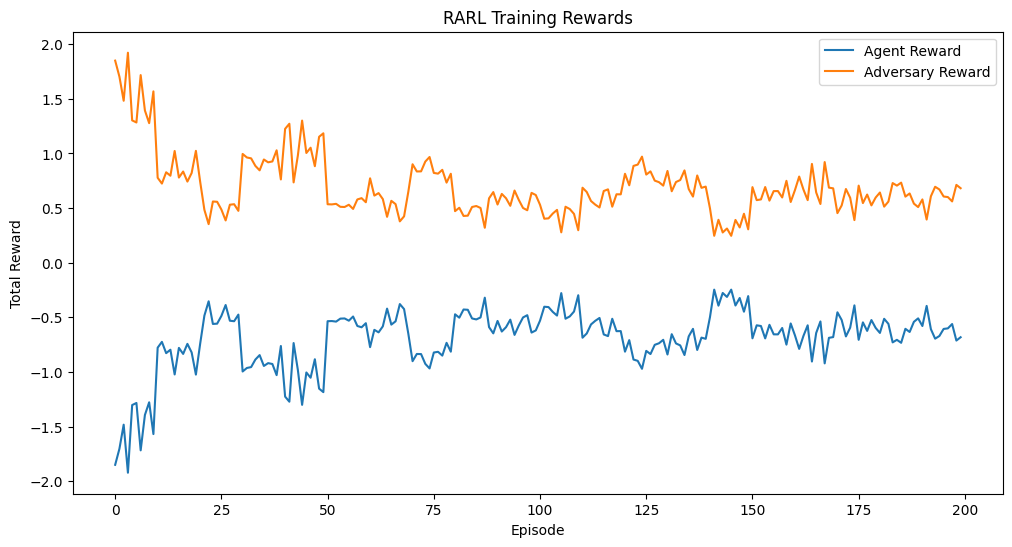

In [103]:
env = BuildingEnv()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
agent = DQNAgent(n_observations=env.observation_space.shape[0], n_actions=env.action_space.n, device=device)
adversary = AdversaryAgent(n_observations=env.observation_space.shape[0], n_actions=env.adversary_action_space.n, device=device)
episodes = 200
agent_rewards, adversary_rewards = train_rarl(agent, adversary, env, episodes)
plot_rarl_rewards(agent_rewards, adversary_rewards)

## Regularizer for Energy
max(self.hvac_power - self.energy_threshold, 0)

In [104]:
class RegularisedBuildingEnv(BuildingEnv):
    metadata = {'render.modes': ['human']}
    def __init__(self, energy_threshold=50, *args):
        super(RegularisedBuildingEnv, self).__init__(*args)
        self.energy_threshold = energy_threshold

    def step(self, action, adversary_action):
        self.setpoint_temp = 22 + action

        temp_difference = self.indoor_temp - self.setpoint_temp
        self.hvac_power = abs(temp_difference) * 10 / self.EER 

        outdoor_influence = (self.outdoor_temp - self.indoor_temp) * 0.1
        hvac_influence = (self.setpoint_temp - self.indoor_temp) * 0.5
        self.indoor_temp += outdoor_influence + hvac_influence

        self.time_step += 1
        done = self.time_step >= self.max_steps
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users = self.generate_num_users()
        self.users = self.generate_users()
        self.user_feedback = self.generate_user_feedback()
        
        if adversary_action == 1:
            self.user_feedback += 0.5
        elif adversary_action == 2:
            self.user_feedback -= 0.5

        self.user_feedback = np.clip(self.user_feedback, -3.0, 3.0)
        if self.num_users == 0:
            reward = -self.beta * (max(self.hvac_power - self.energy_threshold, 0) / 1000.0)  
        else:
            comfort_penalty = abs(self.user_feedback) * self.occupancy_level
            energy_penalty = max(self.hvac_power - self.energy_threshold, 0) / 1000.0
            reward = -(self.alpha * comfort_penalty + self.beta * energy_penalty)
        
        reward = reward / 10.0
        adversary_reward = -reward

        self.history['indoor_temp'].append(self.indoor_temp)
        self.history['outdoor_temp'].append(self.outdoor_temp)
        self.history['hvac_power'].append(self.hvac_power)
        self.history['user_feedback'].append(self.user_feedback)
        self.history['occupancy'].append(self.occupancy_level)
        self.history['time'].append(self.time_step)

        state = np.array([self.outdoor_temp, self.occupancy_level, self.user_feedback], dtype=np.float32)
        return state, reward, done, {}, adversary_reward

/Users/waishunlee/Documents/UROP/hitl_hvac/.venv/lib/python3.10/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Episode 20/200, Avg Agent Reward: -0.64, Avg Adversary Reward: 0.64
Episode 40/200, Avg Agent Reward: -0.61, Avg Adversary Reward: 0.61
Episode 60/200, Avg Agent Reward: -0.54, Avg Adversary Reward: 0.54
Episode 80/200, Avg Agent Reward: -0.60, Avg Adversary Reward: 0.60
Episode 100/200, Avg Agent Reward: -0.55, Avg Adversary Reward: 0.55
Episode 120/200, Avg Agent Reward: -0.62, Avg Adversary Reward: 0.62
Episode 140/200, Avg Agent Reward: -0.62, Avg Adversary Reward: 0.62
Episode 160/200, Avg Agent Reward: -0.59, Avg Adversary Reward: 0.59
Episode 180/200, Avg Agent Reward: -0.60, Avg Adversary Reward: 0.60
Episode 200/200, Avg Agent Reward: -0.62, Avg Adversary Reward: 0.62


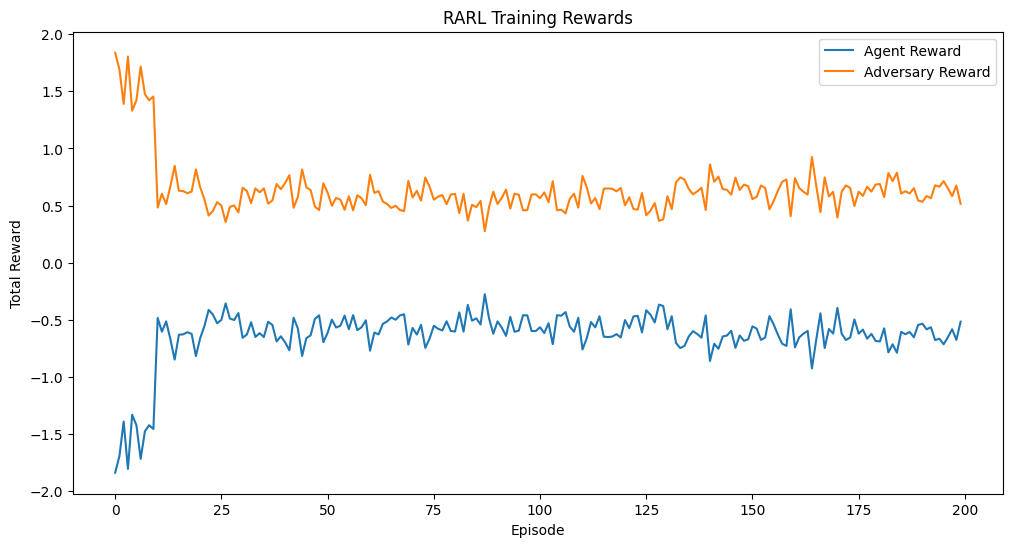

In [129]:
env = RegularisedBuildingEnv()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
agent = DQNAgent(n_observations=env.observation_space.shape[0], n_actions=env.action_space.n, device=device)
adversary = AdversaryAgent(n_observations=env.observation_space.shape[0], n_actions=env.adversary_action_space.n, device=device)
episodes = 200
agent_rewards, adversary_rewards = train_rarl(agent, adversary, env, episodes)
plot_rarl_rewards(agent_rewards, adversary_rewards)

## Evaluating actions of agents

In [126]:
import torch
import numpy as np

def log_actions(env: BuildingEnv, agent, adversary):

    state = env.reset()
    state_agent = torch.tensor([state], device=agent.device, dtype=torch.float32)
    state_adversary = torch.tensor([state], device=adversary.device, dtype=torch.float32)
    total_agent_reward = 0
    total_adversary_reward = 0

    # Storage for analysis
    actions_log = {
        "step": [],
        "agent_action": [],
        "adversary_action": [],
        "setpoint_temp": [],
        "feedback_adjustment": [],
        "indoor_temp": [],
        "user_feedback": [],
        "agent_reward": [],
        "adversary_reward": [],
    }

    for i in range(env.max_steps):
        # Agent and adversary select actions
        action = agent.select_action(state_agent, train=False)
        adversary_action = adversary.select_action(state_adversary, train=False)

        # Decode actions
        agent_setpoint = 22 + action.item()
        adversary_feedback = -0.5 if adversary_action == 0 else (0 if adversary_action == 1 else 0.5)

        # Environment step
        next_state, reward, done, _, adversary_reward = env.step(action.item(), adversary_action.item())

        # Log data
        actions_log["step"].append(i)
        actions_log["agent_action"].append(action.item())
        actions_log["adversary_action"].append(adversary_action.item())
        actions_log["setpoint_temp"].append(agent_setpoint)
        actions_log["feedback_adjustment"].append(adversary_feedback)
        actions_log["indoor_temp"].append(env.indoor_temp)
        actions_log["user_feedback"].append(env.user_feedback)
        actions_log["agent_reward"].append(reward)
        actions_log["adversary_reward"].append(adversary_reward)

        # Convert rewards to tensors
        reward_tensor = torch.tensor([reward], device=agent.device, dtype=torch.float32)
        adversary_reward_tensor = torch.tensor([adversary_reward], device=adversary.device, dtype=torch.float32)

        # Update states
        if not done:
            next_state_agent = torch.tensor([next_state], device=agent.device, dtype=torch.float32)
            next_state_adversary = torch.tensor([next_state], device=adversary.device, dtype=torch.float32)
        else:
            next_state_agent = None
            next_state_adversary = None

        state_agent = next_state_agent
        state_adversary = next_state_adversary

        # Accumulate rewards
        total_agent_reward += reward
        total_adversary_reward += adversary_reward

        # Break if the episode ends
        if done:
            break
    
    return actions_log, total_agent_reward, total_adversary_reward

/Users/waishunlee/Documents/UROP/hitl_hvac/.venv/lib/python3.10/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


In [130]:
# Initialize environment, agent, and adversary
env = RegularisedBuildingEnv()

actions_log, total_agent_reward, total_adversary_reward = log_actions(env, agent, adversary)

# Analysis and Summary
print("\nAnalysis Results:")

# Average and Frequency Analysis
avg_agent_action = np.mean(actions_log["agent_action"])
avg_adversary_action = np.mean(actions_log["adversary_action"])
print(f"Average Agent Action: {avg_agent_action}")
print(f"Average Adversary Action: {avg_adversary_action}")

agent_action_freq = {action: actions_log["agent_action"].count(action) for action in set(actions_log["agent_action"])}
adversary_action_freq = {action: actions_log["feedback_adjustment"].count(action) for action in set(actions_log["feedback_adjustment"])}
print(f"Agent Action Frequency: {agent_action_freq}")
print(f"Adversary Action Frequency: {adversary_action_freq}")

# Reward Trends
print(f"Total Agent Reward: {total_agent_reward}")
print(f"Total Adversary Reward: {total_adversary_reward}")

/Users/waishunlee/Documents/UROP/hitl_hvac/.venv/lib/python3.10/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")



Analysis Results:
Average Agent Action: 0.5
Average Adversary Action: 1.5208333333333333
Agent Action Frequency: {0: 28, 1: 16, 2: 4}
Adversary Action Frequency: {0: 19, 0.5: 27, -0.5: 2}
Total Agent Reward: -0.5714156494064982
Total Adversary Reward: 0.5714156494064982


Adversary action is mainly +0.5 or 0. This is because it increases the perceived discomfort and causes the agent to overcorrect. -0.5 is rarely used, perhaps because the agent is unlikely to undercorrect. Also because the action is only in the set of [0, 1, 2]

Question, is it because there is a limit on end? The actions have all been lopsided towards 22 degrees. 
1. Lower the action space minimum temperature

## Action Space Alternatives

In [122]:
class BuildingEnv20(BuildingEnv):
    metadata = {'render.modes': ['human']}
    def __init__(self, *args):
        super(BuildingEnv20, self).__init__(*args)
        self.action_space = spaces.Discrete(12) 

    def step(self, action, adversary_action):
        self.setpoint_temp = 20 + action * 0.5

        temp_difference = self.indoor_temp - self.setpoint_temp
        self.hvac_power = abs(temp_difference) * 10 / self.EER 

        outdoor_influence = (self.outdoor_temp - self.indoor_temp) * 0.1
        hvac_influence = (self.setpoint_temp - self.indoor_temp) * 0.5
        self.indoor_temp += outdoor_influence + hvac_influence

        self.time_step += 1
        done = self.time_step >= self.max_steps
        self.outdoor_temp = self.generate_outdoor_temperature()
        self.occupancy_level = self.generate_occupancy_level()
        self.num_users = self.generate_num_users()
        self.users = self.generate_users()
        self.user_feedback = self.generate_user_feedback()
        
        if adversary_action == 1:
            self.user_feedback += 0.5
        elif adversary_action == 2:
            self.user_feedback -= 0.5

        self.user_feedback = np.clip(self.user_feedback, -3.0, 3.0)
        if self.num_users == 0:
            reward = -self.beta * (self.hvac_power / 1000.0)  
        else:
            comfort_penalty = abs(self.user_feedback) * self.occupancy_level
            energy_penalty = self.hvac_power / 1000.0
            reward = -(self.alpha * comfort_penalty + self.beta * energy_penalty)
        
        reward = reward / 10.0
        adversary_reward = -reward

        self.history['indoor_temp'].append(self.indoor_temp)
        self.history['outdoor_temp'].append(self.outdoor_temp)
        self.history['hvac_power'].append(self.hvac_power)
        self.history['user_feedback'].append(self.user_feedback)
        self.history['occupancy'].append(self.occupancy_level)
        self.history['time'].append(self.time_step)

        state = np.array([self.outdoor_temp, self.occupancy_level, self.user_feedback], dtype=np.float32)
        return state, reward, done, {}, adversary_reward

/Users/waishunlee/Documents/UROP/hitl_hvac/.venv/lib/python3.10/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Episode 20/200, Avg Agent Reward: -0.63, Avg Adversary Reward: 0.63
Episode 40/200, Avg Agent Reward: -0.62, Avg Adversary Reward: 0.62
Episode 60/200, Avg Agent Reward: -0.58, Avg Adversary Reward: 0.58
Episode 80/200, Avg Agent Reward: -0.59, Avg Adversary Reward: 0.59
Episode 100/200, Avg Agent Reward: -0.57, Avg Adversary Reward: 0.57
Episode 120/200, Avg Agent Reward: -0.59, Avg Adversary Reward: 0.59
Episode 140/200, Avg Agent Reward: -0.55, Avg Adversary Reward: 0.55
Episode 160/200, Avg Agent Reward: -0.65, Avg Adversary Reward: 0.65
Episode 180/200, Avg Agent Reward: -0.62, Avg Adversary Reward: 0.62
Episode 200/200, Avg Agent Reward: -0.65, Avg Adversary Reward: 0.65


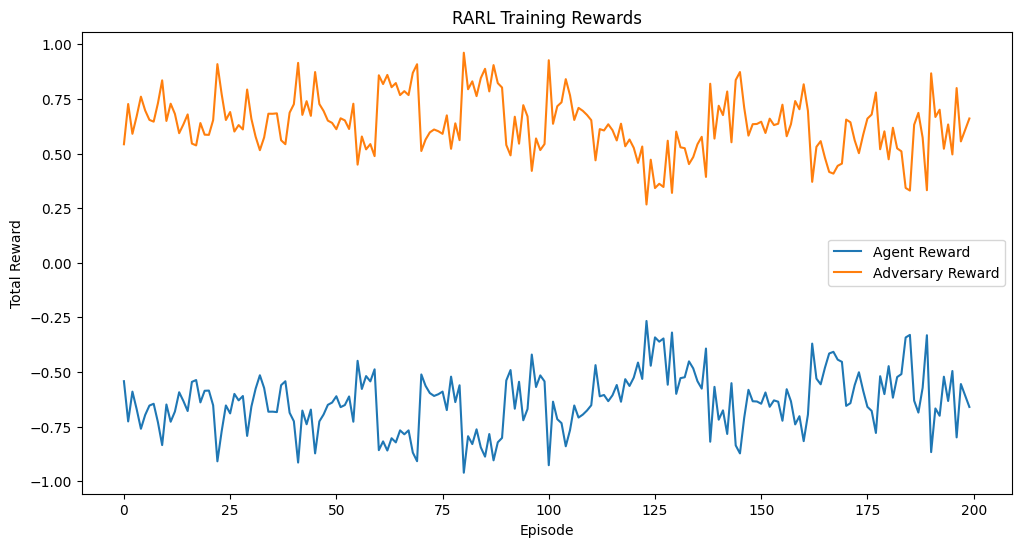

In [131]:
env20 = BuildingEnv20()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
agent20 = DQNAgent(n_observations=env.observation_space.shape[0], n_actions=env.action_space.n, device=device)
adversary20 = AdversaryAgent(n_observations=env.observation_space.shape[0], n_actions=env.adversary_action_space.n, device=device)
episodes = 200
agent_rewards, adversary_rewards = train_rarl(agent, adversary, env, episodes)
plot_rarl_rewards(agent_rewards, adversary_rewards)

In [132]:
actions_log, total_agent_reward, total_adversary_reward = log_actions(env20, agent20, adversary20)

# Analysis and Summary
print("\nAnalysis Results:")

# Average and Frequency Analysis
avg_agent_action = np.mean(actions_log["agent_action"])
avg_adversary_action = np.mean(actions_log["adversary_action"])
print(f"Average Agent Action: {avg_agent_action}")
print(f"Average Adversary Action: {avg_adversary_action}")

agent_action_freq = {action: actions_log["agent_action"].count(action) for action in set(actions_log["agent_action"])}
adversary_action_freq = {action: actions_log["feedback_adjustment"].count(action) for action in set(actions_log["feedback_adjustment"])}
print(f"Agent Action Frequency: {agent_action_freq}")
print(f"Adversary Action Frequency: {adversary_action_freq}")

# Reward Trends
print(f"Total Agent Reward: {total_agent_reward}")
print(f"Total Adversary Reward: {total_adversary_reward}")


Analysis Results:
Average Agent Action: 8.0
Average Adversary Action: 1.0208333333333333
Agent Action Frequency: {8: 48}
Adversary Action Frequency: {0: 47, 0.5: 1}
Total Agent Reward: -1.0808654722874407
Total Adversary Reward: 1.0808654722874407
